<h1>Data Preparation</h1>
<p>This script aims to prepare the data, do the relevant data transformations and create train / test / holdout datasets.</p>

<h2>Import Libraries</h2>
<p>Only import required and used libraries in this script - removed unused libraries</p>

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
import matplotlib.pyplot as plt
import re

<h2>Read Data</h2>
<p>Reading in raw data</p>

In [2]:
cwd = os.getcwd().split('amts')[0] + 'amts'
theme = "machine_learning"

In [3]:
input_folder_path = rf"{cwd}/{theme}/data/inputs/01_lgbm_introduction"

In [4]:
input_file_path = rf"{input_folder_path}/input_data.csv"
print(rf"Input File (Raw Data): {input_file_path}")
raw_input_df = pd.read_csv(input_file_path)

Input File (Raw Data): c:\dev\amts/machine_learning/data/inputs/01_lgbm_introduction/input_data.csv


<h2>Prepare Data</h2>
<p>
Perform data treatments, exclusions or cleaning such as:
<li>Apply any data exclusions</li>
<li>Apply data treatments for outliers</li>
<li>Apply data transformations</li>
</p>

In [5]:
print('\n---Start Data Preparation---')


---Start Data Preparation---


In [6]:
# Always make a copy of the raw input data so that you don't overwrite the original data
prepped_input_df = raw_input_df.copy()

<h3>Analyse Raw Data</h3>

In [7]:
raw_input_df.head()

,id,default_flag,days_past_due,balance,credit_limit,external_score
0,1,0,2,159.014081,700,963
1,2,0,12,1060.501843,1300,569
2,3,0,8,36.357456,1000,640
3,4,0,0,1336.433975,1900,837
4,5,0,0,847.928945,1800,890


In [8]:
raw_input_df.loc[[23]]

,id,default_flag,days_past_due,balance,credit_limit,external_score
23,24,1,0,18.05137,1000,273


In [9]:
raw_input_df.describe()

,id,default_flag,days_past_due,balance,credit_limit,external_score
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,2500.500000,0.338000,23.26040,542.411384,1092.420000,501.740800
std,1443.520003,0.473076,142.42364,472.351800,615.135938,289.460284
min,1.000000,0.000000,0.00000,0.086001,200.000000,0.000000
25%,1250.750000,0.000000,0.00000,171.917607,600.000000,252.000000
50%,2500.500000,0.000000,2.00000,418.373521,1000.000000,507.000000
75%,3750.250000,1.000000,11.00000,780.129874,1500.000000,753.000000
max,5000.000000,1.000000,6273.00000,2833.110912,3400.000000,999.000000


In [10]:
# Add "actual_" in the target variable
prepped_input_df.rename(columns={'default_flag': 'actual_default_flag'}, inplace=True)

<h3>Train/Test Split</h3>
<p>Split the data into 70% train and 30% test</p>

In [11]:
# Filter for observations with <90 DPD
prepped_input_df = prepped_input_df[prepped_input_df['days_past_due'] < 90]
prepped_input_df.describe()

,id,actual_default_flag,days_past_due,balance,credit_limit,external_score
count,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000
mean,2501.103579,0.328632,8.088000,549.827142,1105.073684,509.406737
std,1443.061265,0.469765,14.522796,476.847238,619.036761,289.718957
min,1.000000,0.000000,0.000000,0.086001,200.000000,0.000000
25%,1252.250000,0.000000,0.000000,174.111626,600.000000,260.000000
50%,2503.500000,0.000000,2.000000,429.131831,1000.000000,518.500000
75%,3749.750000,1.000000,9.000000,794.560670,1500.000000,762.000000
max,5000.000000,1.000000,89.000000,2833.110912,3400.000000,999.000000


In [12]:
# Split into 70%/30% train/test
train_input_df, test_input_df = train_test_split(prepped_input_df, train_size=0.70, random_state=42)

In [13]:
train_input_df.describe()

,id,actual_default_flag,days_past_due,balance,credit_limit,external_score
count,3325.000000,3325.000000,3325.000000,3325.000000,3325.000000,3325.000000
mean,2518.932932,0.332331,8.396692,546.942344,1091.067669,500.245113
std,1438.820840,0.471120,14.816972,479.698598,617.817261,291.181654
min,1.000000,0.000000,0.000000,0.086001,200.000000,0.000000
25%,1285.000000,0.000000,0.000000,173.098260,600.000000,248.000000
50%,2534.000000,0.000000,2.000000,419.071318,1000.000000,506.000000
75%,3759.000000,1.000000,9.000000,781.771233,1500.000000,753.000000
max,4999.000000,1.000000,89.000000,2833.110912,3400.000000,999.000000


In [14]:
test_input_df.describe()

,id,actual_default_flag,days_past_due,balance,credit_limit,external_score
count,1425.000000,1425.00000,1425.000000,1425.000000,1425.000000,1425.000000
mean,2459.501754,0.32000,7.367719,556.558336,1137.754386,530.783860
std,1452.563161,0.46664,13.790245,470.225029,620.862040,285.235593
min,9.000000,0.00000,0.000000,0.778127,200.000000,0.000000
25%,1207.000000,0.00000,0.000000,176.990759,700.000000,294.000000
50%,2431.000000,0.00000,2.000000,448.220862,1000.000000,539.000000
75%,3722.000000,1.00000,8.000000,817.689852,1600.000000,784.000000
max,5000.000000,1.00000,89.000000,2637.748806,3200.000000,999.000000


<h3>Create Default Rate Chart</h3>
<p>Create a line chart with days past due against default rate</p>

In [15]:
# Create default rate column
chart_input_df = train_input_df.groupby(['days_past_due'])['actual_default_flag'].agg(['count', 'sum']).reset_index()
chart_input_df['total_count'] = chart_input_df['count'].sum()
chart_input_df['default_rate'] = chart_input_df['sum'] / chart_input_df['count']
chart_input_df.head()

,days_past_due,count,sum,total_count,default_rate
0,0,1096,226,3325,0.206204
1,1,413,103,3325,0.249395
2,2,246,73,3325,0.296748
3,3,189,59,3325,0.312169
4,4,147,49,3325,0.333333


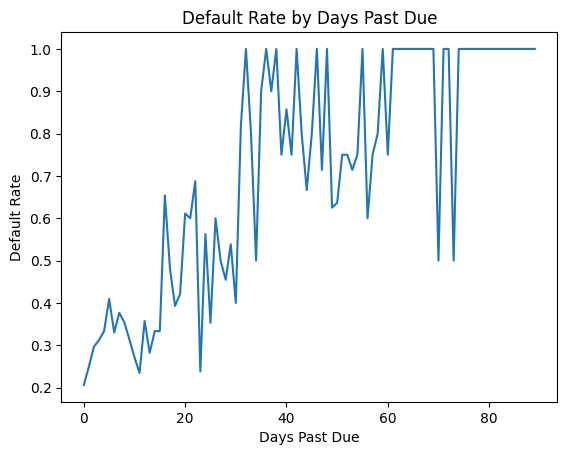

In [16]:
plt.plot(chart_input_df[['days_past_due']], chart_input_df[['default_rate']])
plt.title('Default Rate by Days Past Due')
plt.xlabel('Days Past Due')
plt.ylabel('Default Rate')
plt.show()

<h3>Create Bins and Calculate WoE</h3>
<p>A tree classifer model is first trained and its bins are then used. Weight of Evidence (WoE) for each bin is then calculated.</p>

<h4>Set up tree classifier model for binning</h4>

In [17]:
class TreeClassifierBinner:
    def __init__(self, input_train_data: pd.DataFrame, input_test_data: pd.DataFrame, feature_to_bin: str, target_variable_column: str, max_leaf_nodes: int = 10
                 ) -> {tree, pd.DataFrame, pd.DataFrame, pd.DataFrame}:
        self.input_train_data = input_train_data
        self.input_test_data = input_test_data
        self.feature_to_bin = feature_to_bin
        self.target_variable_column = target_variable_column
        self.max_leaf_nodes = max_leaf_nodes
    
    def run(self):
        # Train model and calculate WoE on train data
        self.tree_classifier_model = self.train_tree_classifier_model()
        self.tree_bins_list = self.get_tree_bins()
        
        self.prepped_input_train_data = self._add_tree_bins_columns(self.input_train_data)
        
        self.grouped_input_train_data = self.get_default_rates_by_bins()
        self.woe_output_data = self.calculate_woe_and_iv()
        self.output_train_data = self._add_woe_column(self.prepped_input_train_data)

        # Add the same WoE onto test data
        self.prepped_input_test_data = self._add_tree_bins_columns(self.input_test_data)
        self.output_test_data = self._add_woe_column(self.prepped_input_test_data)

        return self.tree_classifier_model, self.woe_output_data, self.output_train_data, self.output_test_data

    def train_tree_classifier_model(self) -> tree: 
        # Train a decision tree classifier model
        tree_classifier_model = DecisionTreeClassifier(max_leaf_nodes=self.max_leaf_nodes, random_state=0)
        x = self.input_train_data[[self.feature_to_bin]]
        y = self.input_train_data[[self.target_variable_column]]
        tree_classifier_model.fit(x, y)
        return tree_classifier_model

    def get_tree_bins(self) -> list:
        # Get the tree bins in a list
        tree_texts = tree.export_text(self.tree_classifier_model, feature_names=[self.feature_to_bin])
        bins_list = re.sub("class: [0-9]", "", tree_texts)
        bins_list = re.sub("[^0-9., ]", "", bins_list)
        bins_list = re.sub(" +", ", ", bins_list.strip()).split(", ")
        bins_list = list(set([float(x) for x in bins_list])) + [float("-inf"), float("+inf")]
        bins_list.sort()
        return bins_list

    def get_default_rates_by_bins(self) -> pd.DataFrame:
        # Get the default rates by bins
        output_df = self.prepped_input_train_data.groupby(f'{self.feature_to_bin}_bin', observed=False)[self.target_variable_column].agg(['count', 'sum']).reset_index()
        output_df['total_count'] = output_df['count'].sum()
        output_df['default_rate'] = output_df['sum'] / output_df['count']
        return output_df
    
    def calculate_woe_and_iv(self) -> pd.DataFrame:
        # Calculate WoE and IV
        output_df = self.grouped_input_train_data.copy()

        output_df['non_defaults'] = output_df['count'] - output_df['sum']
        total_defaults_int = output_df['sum'].sum()
        total_non_defaults_int = output_df['non_defaults'].sum()
        
        output_df['default_percentage'] = output_df['sum'] / total_defaults_int
        output_df['non_default_percentage'] = output_df['non_defaults'] / total_non_defaults_int

        output_df[f'{self.feature_to_bin}_woe'] = np.log(output_df['default_percentage'] / output_df['non_default_percentage'])
        output_df['iv'] = np.sum(-output_df[f'{self.feature_to_bin}_woe'] * (output_df['non_default_percentage'] - output_df['default_percentage']))
        return output_df

    def _add_tree_bins_columns(self, input_df) -> pd.DataFrame:
        # Add the bins to input data
        output_df = input_df.copy()
        output_df[f'{self.feature_to_bin}_bin'] = pd.cut(output_df[self.feature_to_bin], self.tree_bins_list)
        return output_df

    def _add_woe_column(self, input_df) -> pd.DataFrame:
        output_df = pd.merge(input_df, self.woe_output_data[[f'{self.feature_to_bin}_bin', f'{self.feature_to_bin}_woe']], on=[f'{self.feature_to_bin}_bin'], how='left')
        return output_df

<h4>Single feature example</h4>

In [18]:
dpd_tree_binner, dpd_woe_output_df, train_with_dpd_bins_df, test_with_dpd_bins_df = TreeClassifierBinner(train_input_df, test_input_df, 'days_past_due', 'actual_default_flag', 4).run()

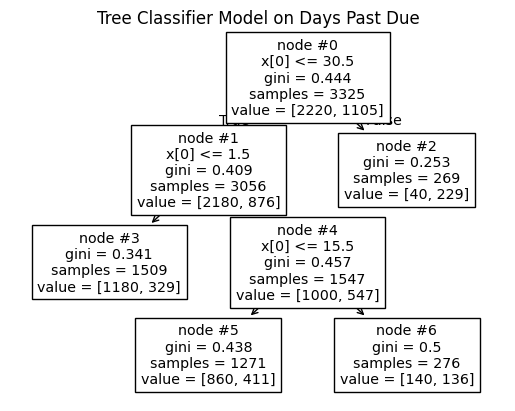

In [19]:
# Show the tree in a plot
tree.plot_tree(dpd_tree_binner, node_ids=True)
plt.title('Tree Classifier Model on Days Past Due')
plt.show()

In [20]:
dpd_woe_output_df

,days_past_due_bin,count,sum,total_count,default_rate,non_defaults,default_percentage,non_default_percentage,days_past_due_woe,iv
0,"(-inf, 1.5]",1509,329,3325,0.218025,1180,0.297738,0.531532,-0.579550,0.638428
1,"(1.5, 15.5]",1271,411,3325,0.323367,860,0.371946,0.387387,-0.040677,0.638428
2,"(15.5, 30.5]",276,136,3325,0.492754,140,0.123077,0.063063,0.668674,0.638428
3,"(30.5, inf]",269,229,3325,0.851301,40,0.207240,0.018018,2.442504,0.638428


In [21]:
train_with_dpd_bins_df.head()

,id,actual_default_flag,days_past_due,balance,credit_limit,external_score,days_past_due_bin,days_past_due_woe
0,2856,0,2,17.197143,600,546,"(1.5, 15.5]",-0.040677
1,1253,0,40,1309.348363,1400,842,"(30.5, inf]",2.442504
2,2889,0,2,2256.716616,2600,994,"(1.5, 15.5]",-0.040677
3,1821,0,0,659.401525,700,607,"(-inf, 1.5]",-0.579550
4,3725,1,0,356.882343,1000,594,"(-inf, 1.5]",-0.579550


In [22]:
test_with_dpd_bins_df.head()

,id,actual_default_flag,days_past_due,balance,credit_limit,external_score,days_past_due_bin,days_past_due_woe
0,4015,0,3,1013.419228,2500,809,"(1.5, 15.5]",-0.040677
1,1132,1,10,195.385213,200,67,"(1.5, 15.5]",-0.040677
2,315,1,11,1096.141677,1600,579,"(1.5, 15.5]",-0.040677
3,2152,0,3,722.423499,2800,906,"(1.5, 15.5]",-0.040677
4,1790,0,2,135.213846,2100,728,"(1.5, 15.5]",-0.040677


<h4>Create bins across all features</h4>

In [23]:
# Create a mapping which includes the features you would like to bin and its corresponding number of bins (max leaf nodes)
features_to_max_leaf_nodes_mapping_dict = {
    'days_past_due' : 5,
    'balance' : 3,
    'credit_limit' : 5,
    'external_score' : 5
}

In [24]:
# Initiate the creation of the tree binner class for each feature
train_with_bins_df = train_input_df.copy()
test_with_bins_df = test_input_df.copy()

print('WoE')
for feature_str, max_leaf_nodes_int in features_to_max_leaf_nodes_mapping_dict.items():
    print(f'--Feature: {feature_str}--')
    _, woe_output_df, train_with_bins_df, test_with_bins_df = TreeClassifierBinner(train_with_bins_df, test_with_bins_df, feature_str, 'actual_default_flag', max_leaf_nodes_int).run()
    print(woe_output_df[[f'{feature_str}_bin', f'{feature_str}_woe', 'iv']])
    print('\n')

WoE
--Feature: days_past_due--
  days_past_due_bin  days_past_due_woe       iv
0       (-inf, 1.5]          -0.579550  0.69811
1       (1.5, 15.5]          -0.040677  0.69811
2      (15.5, 30.5]           0.668674  0.69811
3      (30.5, 60.5]           2.172063  0.69811
4       (60.5, inf]           4.147649  0.69811


--Feature: balance--
         balance_bin  balance_woe       iv
0     (-inf, 138.68]     0.350854  0.13269
1  (138.68, 1121.69]     0.041654  0.13269
2     (1121.69, inf]    -1.035990  0.13269


--Feature: credit_limit--
   credit_limit_bin  credit_limit_woe        iv
0     (-inf, 250.0]          0.661028  0.344891
1   (250.0, 1150.0]          0.340847  0.344891
2  (1150.0, 1350.0]         -0.228108  0.344891
3  (1350.0, 1750.0]         -0.549483  0.344891
4     (1750.0, inf]         -1.264676  0.344891


--Feature: external_score--
  external_score_bin  external_score_woe        iv
0      (-inf, 191.5]            1.174170  0.977136
1     (191.5, 450.5]            0.4745

In [25]:
train_with_bins_df.head()

,id,actual_default_flag,days_past_due,balance,credit_limit,external_score,days_past_due_bin,days_past_due_woe,balance_bin,balance_woe,credit_limit_bin,credit_limit_woe,external_score_bin,external_score_woe
0,2856,0,2,17.197143,600,546,"(1.5, 15.5]",-0.040677,"(-inf, 138.68]",0.350854,"(250.0, 1150.0]",0.340847,"(450.5, 623.5]",0.040480
1,1253,0,40,1309.348363,1400,842,"(30.5, 60.5]",2.172063,"(1121.69, inf]",-1.035990,"(1350.0, 1750.0]",-0.549483,"(702.5, inf]",-1.744685
2,2889,0,2,2256.716616,2600,994,"(1.5, 15.5]",-0.040677,"(1121.69, inf]",-1.035990,"(1750.0, inf]",-1.264676,"(702.5, inf]",-1.744685
3,1821,0,0,659.401525,700,607,"(-inf, 1.5]",-0.579550,"(138.68, 1121.69]",0.041654,"(250.0, 1150.0]",0.340847,"(450.5, 623.5]",0.040480
4,3725,1,0,356.882343,1000,594,"(-inf, 1.5]",-0.579550,"(138.68, 1121.69]",0.041654,"(250.0, 1150.0]",0.340847,"(450.5, 623.5]",0.040480


In [26]:
test_with_bins_df.head()

,id,actual_default_flag,days_past_due,balance,credit_limit,external_score,days_past_due_bin,days_past_due_woe,balance_bin,balance_woe,credit_limit_bin,credit_limit_woe,external_score_bin,external_score_woe
0,4015,0,3,1013.419228,2500,809,"(1.5, 15.5]",-0.040677,"(138.68, 1121.69]",0.041654,"(1750.0, inf]",-1.264676,"(702.5, inf]",-1.744685
1,1132,1,10,195.385213,200,67,"(1.5, 15.5]",-0.040677,"(138.68, 1121.69]",0.041654,"(-inf, 250.0]",0.661028,"(-inf, 191.5]",1.174170
2,315,1,11,1096.141677,1600,579,"(1.5, 15.5]",-0.040677,"(138.68, 1121.69]",0.041654,"(1350.0, 1750.0]",-0.549483,"(450.5, 623.5]",0.040480
3,2152,0,3,722.423499,2800,906,"(1.5, 15.5]",-0.040677,"(138.68, 1121.69]",0.041654,"(1750.0, inf]",-1.264676,"(702.5, inf]",-1.744685
4,1790,0,2,135.213846,2100,728,"(1.5, 15.5]",-0.040677,"(-inf, 138.68]",0.350854,"(1750.0, inf]",-1.264676,"(702.5, inf]",-1.744685


In [27]:
print('--Correlation Matrix--')

features_for_correlation_matrix_list = [x for x in train_with_bins_df.columns if '_woe' in x]
correlation_df = train_with_bins_df[features_for_correlation_matrix_list].copy()
print(correlation_df.corr())

--Correlation Matrix--
                    days_past_due_woe  balance_woe  credit_limit_woe  \
days_past_due_woe            1.000000     0.084520          0.149784   
balance_woe                  0.084520     1.000000          0.551121   
credit_limit_woe             0.149784     0.551121          1.000000   
external_score_woe           0.224859     0.430502          0.728293   

                    external_score_woe  
days_past_due_woe             0.224859  
balance_woe                   0.430502  
credit_limit_woe              0.728293  
external_score_woe            1.000000  


In [28]:
print('---End Data Preparation---\n')

---End Data Preparation---



<h2>Output Data</h2>
<p>Output prepped data for model build - always have <b>index=False</b> to make sure no index are outputted</p>

In [29]:
output_folder_path = rf"{cwd}/{theme}/data/outputs/01_lgbm_introduction"

In [30]:
output_file_path = rf"{output_folder_path}/train_input_df.csv"
print(rf"Output File (Train Data): {output_file_path}")
train_with_bins_df.to_csv(output_file_path, index=False)

Output File (Train Data): c:\dev\amts/machine_learning/data/outputs/01_lgbm_introduction/train_input_df.csv


In [31]:
output_file_path = rf"{output_folder_path}/test_input_df.csv"
print(rf"Output File (Test Data): {output_file_path}")
test_with_bins_df.to_csv(output_file_path, index=False)

Output File (Test Data): c:\dev\amts/machine_learning/data/outputs/01_lgbm_introduction/test_input_df.csv
